# CNNs & Resnets

In this section I'll review my neural networks knowledge, it has been a while since I programmed one of those. Will start by making very simply neural network and will assemble a Resnet34 in the end.

## The Basics of NNs

The objectives are to learn how to create my own torch module.

In [21]:
import sys
import math
from pathlib import Path
sys.path.insert(0, './arena_helpers')
print(Path.cwd())
import arena_helpers.tests as tests
import json
from collections import namedtuple
from dataclasses import dataclass
from pathlib import Path

import einops
import numpy as np
import torch as t
import torch.nn as nn
import torch.nn.functional as F
import torchinfo
from IPython.display import display
from jaxtyping import Float, Int
from PIL import Image
from rich import print as rprint
from rich.table import Table
from torch import Tensor
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from tqdm.notebook import tqdm
from plotly_utils import line

/home/youssef/projects/AI-safety/arena-3.0/prereqs/cnn-resnets


Don't forget to make a `device` global variable

In [23]:
device = t.device("cuda" if t.cuda.is_available() else "cpu")
device

device(type='cuda')

### Implementing ReLU

let's now fill the `forward` method of the `ReLU` class.

In [31]:
class ReLU(nn.Module):
    def forward(self, x: Tensor) -> Tensor:
        y = t.maximum(t.zeros((1),device=x.device),x) #make use of broadcasting
        return y


tests.test_relu(ReLU)

All tests in `test_relu` passed!


### Implementing Linear

we'll implement a `Linear` module, that does a linear transformation.

In [5]:
t.distributions.Uniform(2, 10).sample((5,))

tensor([6.5141, 4.1272, 8.9776, 4.3074, 3.7421])

In [40]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias=True):
        """
        A simple linear (technically, affine) transformation.

        The fields should be named `weight` and `bias` for compatibility with PyTorch.
        If `bias` is False, set `self.bias` to None.
        """
        super().__init__()
        # let's initialize weights
        self.bound = 1/ math.sqrt(in_features)
        self.is_bias = bias
        self.in_features = in_features
        self.out_features = out_features

        self.weight = nn.Parameter(t.distributions.Uniform(-self.bound, self.bound).sample((out_features, in_features)))
        if self.is_bias:
            self.bias = nn.Parameter(t.zeros(out_features))
        else:
            self.bias = None
    def forward(self, x: Tensor) -> Tensor:
        """
        x: shape (*, in_features)
        Return: shape (*, out_features)
        """
        y = x @ self.weight.T
        if self.is_bias:
            y += self.bias

        return y

    def extra_repr(self) -> str:
        return f"in_features={self.in_features}, out_features={self.out_features}, is_biased={self.is_bias}"


tests.test_linear_parameters(Linear, bias=False)
tests.test_linear_parameters(Linear, bias=True)
tests.test_linear_forward(Linear, bias=False)
tests.test_linear_forward(Linear, bias=True)

All tests in `test_linear_parameters` passed!
All tests in `test_linear_parameters` passed!
All tests in `test_linear_forward` passed!
All tests in `test_linear_forward` passed!


### Flatten

In [41]:
class Flatten(nn.Module):
    def __init__(self, start_dim: int = 1, end_dim: int = -1) -> None:
        super().__init__()
        self.start_dim = start_dim
        self.end_dim = end_dim

    def forward(self, input: Tensor) -> Tensor:
        """
        Flatten out dimensions from start_dim to end_dim, inclusive of both.
        """
        shape = input.shape

        # Get start & end dims, handling negative indexing for end dim
        start_dim = self.start_dim
        end_dim = self.end_dim if self.end_dim >= 0 else len(shape) + self.end_dim

        # Get the shapes to the left / right of flattened dims, as well as size of flattened middle
        shape_left = shape[:start_dim]
        shape_right = shape[end_dim + 1 :]
        shape_middle = t.prod(t.tensor(shape[start_dim : end_dim + 1])).item()

        return t.reshape(input, shape_left + (shape_middle,) + shape_right)

    def extra_repr(self) -> str:
        return ", ".join([f"{key}={getattr(self, key)}" for key in ["start_dim", "end_dim"]])

## Full MLP

We'll implement an MLP with this architecture

 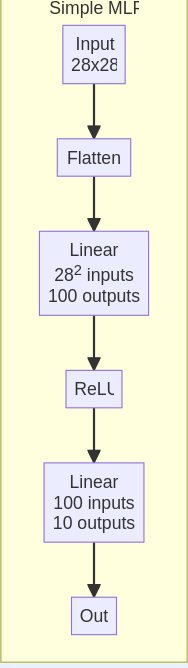

In [42]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = Linear(784, 100, True)
        self.linear2 = Linear(100, 10, True) 
        self.flatten = Flatten(1,-1) # to flatten to 28*28, remember not to flatten batch
        self.relu = ReLU()

    def forward(self, x: Tensor) -> Tensor:
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.relu(x)
        y = self.linear2(x)
        return y
        


tests.test_mlp_module(SimpleMLP)
tests.test_mlp_forward(SimpleMLP)

All tests in `test_mlp_module` passed!
All tests in `test_mlp_forward` passed!


# Training NN

- learn how to deal with transforms, datasets and dataloaders
- basic structure of a training loop
- writing a validation loop

In [10]:
Path.cwd()

PosixPath('/home/youssef/projects/AI-safety/arena-3.0/prereqs/cnn-resnets')

In [43]:
MNIST_TRANSFORM = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(0.1307, 0.3081),
    ]
)



def get_mnist(trainset_size: int = 10_000, testset_size: int = 1_000) -> tuple[Subset, Subset]:
    """Returns a subset of MNIST training data."""

    # Get original datasets, which are downloaded to "./data" for future use
    mnist_trainset = datasets.MNIST( "data", train=True, download=True, transform=MNIST_TRANSFORM)
    mnist_testset = datasets.MNIST( "data", train=False, download=True, transform=MNIST_TRANSFORM)

    # # Return a subset of the original datasets
    mnist_trainset = Subset(mnist_trainset, indices=range(trainset_size))
    mnist_testset = Subset(mnist_testset, indices=range(testset_size))

    return mnist_trainset, mnist_testset


mnist_trainset, mnist_testset = get_mnist()
mnist_trainloader = DataLoader(mnist_trainset, batch_size=64, shuffle=True)
mnist_testloader = DataLoader(mnist_testset, batch_size=64, shuffle=False)

# Get the first batch of test data, by starting to iterate over `mnist_testloader`
for img_batch, label_batch in mnist_testloader:
    print(f"{img_batch.shape=}\n{label_batch.shape=}\n")
    break

# Get the first datapoint in the test set, by starting to iterate over `mnist_testset`
for img, label in mnist_testset:
    print(f"{img.shape=}\n{label=}\n")
    break

t.testing.assert_close(img, img_batch[0])
assert label == label_batch[0].item()


img_batch.shape=torch.Size([64, 1, 28, 28])
label_batch.shape=torch.Size([64])

img.shape=torch.Size([1, 28, 28])
label=7



- Here we used the `torchvision` package that has popular datasets.
- `torchvision.transforms` has access to suite of functions for preprocessing data.
- `torchvision.datasets` gets us the datasets, takes as arguments where to save data, transforms.
- `Dataloader`, wraps the datasets to work on **Batches**, also takes as an argument `shuffle` which randomizes the order after each epoch.
- we use `tqdm` which shows progress bars as seen below.

In [18]:
import time
word = "hello!"
pbar = tqdm(enumerate(word), total=len(word))
t0 = time.time()

for i, letter in pbar:
    time.sleep(1.0)
    pbar.set_postfix(i=i, letter=letter, time=f"{time.time()-t0:.3f}")
    pbar.set_description("shows the progress of the word hello")

  0%|          | 0/6 [00:00<?, ?it/s]

## Training Loop

A very simple training loop, which can run to train your model.

In [45]:
model = SimpleMLP().to(device)

batch_size = 128
epochs = 3

mnist_trainset, _ = get_mnist()
mnist_trainloader = DataLoader(mnist_trainset, batch_size=batch_size, shuffle=True)

optimizer = t.optim.Adam(model.parameters(), lr=1e-3)
loss_list = []

for epoch in range(epochs):
    pbar = tqdm(mnist_trainloader)

    for imgs, labels in pbar:
        # Move data to device, perform forward pass
        imgs, labels = imgs.to(device), labels.to(device)

        logits = model(imgs)

        # Calculate loss, perform backward pass
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Update logs & progress bar
        loss_list.append(loss.item())
        pbar.set_postfix(epoch=f"{epoch + 1}/{epochs}", loss=f"{loss:.3f}")

line(
    loss_list,
    x_max=epochs * len(mnist_trainset),
    labels={"x": "Examples seen", "y": "Cross entropy loss"},
    title="SimpleMLP training on MNIST",
    width=700,
)


  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Our training loop consists of:
1. evaluating the model on batch of data -> get logits and class predictions
2. calculate loss between logits & true class labels
3. backprop the loss
4. make a stop using out opimizer
5. zero out the gradients of the optimizer

## Refactoring Code

When we have a lot of input parameters. We use dataclasses to keep track of them. Here's an example of the above code but using a dataclass. Let's also a validation loop.

In [50]:
t.rand((64,10)).max(dim=-1)

torch.return_types.max(
values=tensor([0.9709, 0.8897, 0.9283, 0.9937, 0.8969, 0.8391, 0.9530, 0.9562, 0.8318,
        0.9157, 0.9948, 0.9554, 0.8668, 0.7398, 0.9962, 0.8011, 0.9709, 0.8059,
        0.9968, 0.9304, 0.7368, 0.8525, 0.8890, 0.9020, 0.9759, 0.9308, 0.8999,
        0.9426, 0.9161, 0.7802, 0.8599, 0.8602, 0.9414, 0.9368, 0.9252, 0.8097,
        0.8604, 0.9458, 0.7373, 0.9696, 0.9495, 0.8507, 0.8492, 0.8928, 0.9521,
        0.9645, 0.9175, 0.7696, 0.9854, 0.8658, 0.6819, 0.9828, 0.9381, 0.7714,
        0.8857, 0.9687, 0.9499, 0.9881, 0.8986, 0.8895, 0.9749, 0.9782, 0.8716,
        0.9114]),
indices=tensor([0, 7, 7, 5, 3, 2, 0, 4, 5, 9, 2, 7, 2, 1, 6, 8, 2, 9, 8, 6, 1, 3, 2, 7,
        2, 6, 9, 7, 8, 7, 6, 4, 9, 8, 7, 3, 7, 5, 5, 6, 5, 8, 5, 7, 0, 9, 3, 3,
        9, 9, 4, 9, 8, 5, 8, 3, 4, 4, 0, 6, 3, 5, 1, 5]))

In [65]:
@dataclass
class SimpleMLPTrainingArgs:
    """
    Defining this class implicitly creates an __init__ method, which sets arguments as below, e.g.
    self.batch_size=64. Any of these fields can also be overridden when you create an instance, e.g.
    SimpleMLPTrainingArgs(batch_size=128).
    """

    batch_size: int = 64
    epochs: int = 3
    learning_rate: float = 1e-3


def train(args: SimpleMLPTrainingArgs) -> tuple[list[float], list[float], SimpleMLP]:
    """
    Trains & returns the model, using training parameters from the `args` object. Returns the model,
    and loss list.
    """
    model = SimpleMLP().to(device)

    mnist_trainset, mnist_testset = get_mnist()
    mnist_trainloader = DataLoader(mnist_trainset, batch_size=args.batch_size, shuffle=True)
    mnist_val_loader = DataLoader(mnist_testset, batch_size=args.batch_size, shuffle=False)
    optimizer = t.optim.Adam(model.parameters(), lr=args.learning_rate)
    loss_list = []
    accuracies = [] #for the validation loop 

    for epoch in range(args.epochs):
        pbar = tqdm(mnist_trainloader)

        for imgs, labels in pbar:
            # Move data to device, perform forward pass
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)

            # Calculate loss, perform backward pass
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Update logs & progress bar
            loss_list.append(loss.item())
            pbar.set_postfix(epoch=f"{epoch + 1}/{args.epochs}", loss=f"{loss:.3f}")

        # the validation loop
        val_pbar = tqdm(mnist_val_loader)
        accuracy, total_size = 0, 0 # reinitialized after every epoch
        for val_imgs, val_labels in val_pbar:
            
            # move data to device
            val_imgs, val_labels = val_imgs.to(device), val_labels.to(device)

            # get prediction of the model on the validation images
            val_logits = model(val_imgs)
            # apply softmax for predictions to be normalized
            val_preds = F.softmax(val_logits,dim=-1)

            # get accuracy of model
            _, pred_class = t.max(val_preds, dim=-1)
            batch_accuracy = (pred_class == val_labels).int().sum()
            batch_size = val_imgs.shape[0]
            total_size += batch_size
            accuracy += batch_accuracy
        accuracies.append(accuracy.item()/total_size) 
            

    return loss_list, accuracies, model


args = SimpleMLPTrainingArgs()
loss_list, accuracies, model = train(args)

line(
    y=[loss_list, [0.1] + accuracies],  # we start by assuming a uniform accuracy of 10%
    use_secondary_yaxis=True,
    x_max=args.epochs * len(mnist_trainset),
    labels={"x": "Num examples seen", "y1": "Cross entropy loss", "y2": "Test Accuracy"},
    title="SimpleMLP training on MNIST",
    width=800,
)


  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]